In [33]:
# Abhängigkeiten installieren
#!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow statsmodels hmmlearn

# Zum Updaten von yfinance:
#!pip install --upgrade yfinance

### Phase 1: Datenbeschaffung & Preprocessing
Zuerst benötigst wir die Rohdaten. Der Zeitraum von mindestens 20-30 Jahren ist ideal (um mehrere Zyklen wie 2000, 2008 und 2020 abzudecken).

*   **Libraries:** `yfinance`, `pandas`, `numpy`
*   **Datenquellen:**
    *   **Risiko-Asset:** 60% S&P 500 (Ticker: `^GSPC`), 40% US-Staatsanleihen (Ticker: `VUSTX`)
    *   **Safe-Haven:** 3-Monats-Treasury Bill Rate als Proxy für Cash-Zinsen(Ticker: `^IRX`)
    *   **Features:** VIX Index (Volatilität), Renditestrukturkurve (10Y-2Y Spread), Momentum-Indikatoren.

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Daten laden
# ^GSPC = S&P 500 | VUSTX = Long Bonds | ^VIX = Volatilität | ^IRX = 3-Monats-Zins | ^TNX = 10-Jahres-Zins
tickers = ["^GSPC", "VUSTX", "^VIX", "^IRX", "^TNX"]
start_date = "1990-01-02" 
end_date = "2025-12-31"

# Alles ohne Index-Zugriff runterladen
raw_data = yf.download(tickers, start=start_date, end=end_date)

# --- ROBUSTER MULTI-INDEX FIX (Keyerror-Fix) ---
# Wir prüfen, welcher Preis-Typ verfügbar ist ('Adj Close' bevorzugt, sonst 'Close') - In neueren yfinance-Versionen wurde 'Adj Close' oft durch 'Close' ersetzt, wenn die Daten bereits bereinigt sind. Prüfung beider Case
if 'Adj Close' in raw_data.columns.get_level_values(0):
    data = raw_data['Adj Close'].copy()
    print("Nutze 'Adj Close'")
else:
    data = raw_data['Close'].copy()
    print("Nutze 'Close' (Adj Close nicht gefunden)")
    
# Füllen der Lücken beim Zins (^IRX), da dieser seltener schwankt
data['^IRX'] = data['^IRX'].ffill()
data = data.dropna()

# Jetzt haben wir ein "flaches" DataFrame mit den Tickern als Spalten
data = data.dropna()

# 2. Portfolio Erstellung (60% S&P 500, 40% Long Term Bonds)
returns = data.pct_change().dropna()

# Direkter Zugriff auf die Spaltennamen
weights = np.array([0.60, 0.40])
portfolio_returns = (returns[["^GSPC", "VUSTX"]] * weights).sum(axis=1)

df = pd.DataFrame(index=portfolio_returns.index)

# Einzel-Returns von S&P 500 und Bonds
df['Returns_GSPC'] = returns['^GSPC']
df['Returns_VUSTX'] = returns['VUSTX']

df['Returns'] = portfolio_returns
df['Cumulative_Returns'] = (1 + df['Returns']).cumprod()

# --- CASH-RENDITE INTEGRATION ---
# ^IRX gibt die jährliche Rendite in % an. Umrechnung in tägliche Rendite:
# (Wert / 100) / 252 Handelstage
df['Cash_Returns'] = (data['^IRX'] / 100) / 252

df = df.dropna()
print(f"Erfolgreich geladen: {df.index[0].date()} bis {df.index[-1].date()}")

print(df)

[*********************100%***********************]  5 of 5 completed

Nutze 'Close' (Adj Close nicht gefunden)
Erfolgreich geladen: 1990-01-03 bis 2025-12-30
            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-01-03     -0.002586      -0.003020 -0.002759            0.997241   
1990-01-04     -0.008613       0.000000 -0.005168            0.992087   
1990-01-05     -0.009756      -0.002020 -0.006662            0.985478   
1990-01-08      0.004514      -0.003036  0.001494            0.986951   
1990-01-09     -0.011787       0.000000 -0.007072            0.979971   
...                  ...            ...       ...                 ...   
2025-12-23      0.004550       0.001255  0.003232           20.224213   
2025-12-24      0.003221       0.005013  0.003938           20.303854   
2025-12-26     -0.000304      -0.002494 -0.001180           20.279893   
2025-12-29     -0.003492       0.003750 -0.000595           20.267821   
2025-12-30     -0.001376      -0.001

### Phase 2: Feature Engineering (Der "Signal-Geber")
Modelle benötigen Input, um Regimes zu erkennen. Wir wandeln Rohdaten in stationäre Features um.

Features erfolgreich erstellt. Spalten im DataFrame: ['Returns_GSPC', 'Returns_VUSTX', 'Returns', 'Cumulative_Returns', 'Cash_Returns', 'Vol_20', 'SMA_200', 'Distance_SMA', 'Momentum', 'VIX', 'Yield_Spread']


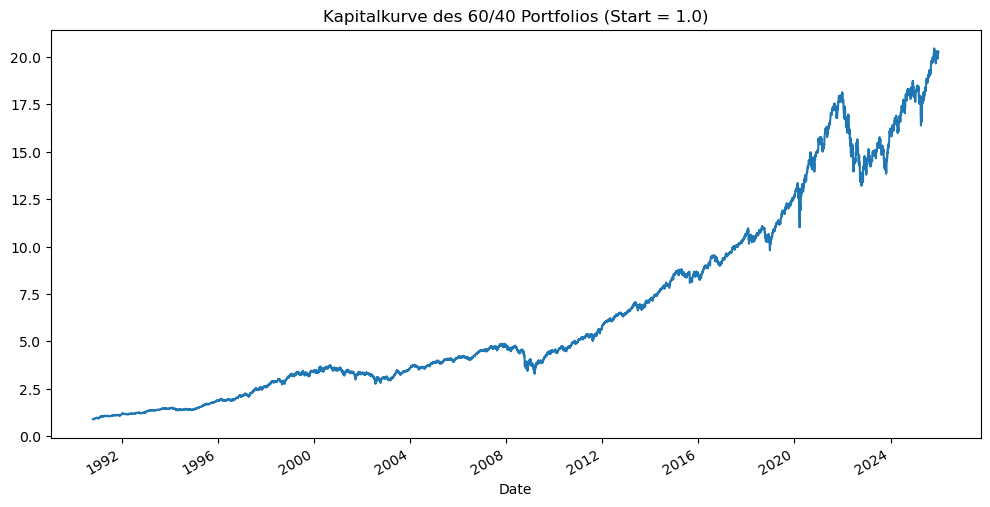

            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-10-18      0.023363       0.006586  0.016652            0.902546   
1990-10-19      0.022045       0.008724  0.016716            0.917633   
1990-10-22      0.007296      -0.001081  0.003946            0.921254   
1990-10-23     -0.007625      -0.002165 -0.005441            0.916241   
1990-10-24      0.000768      -0.001085  0.000027            0.916266   
...                  ...            ...       ...                 ...   
2025-12-23      0.004550       0.001255  0.003232           20.224213   
2025-12-24      0.003221       0.005013  0.003938           20.303854   
2025-12-26     -0.000304      -0.002494 -0.001180           20.279893   
2025-12-29     -0.003492       0.003750 -0.000595           20.267821   
2025-12-30     -0.001376      -0.001245 -0.001323           20.240997   

            Cash_Returns    Vol_20    SMA_200  Dis

In [35]:
# --- Phase 2: Feature Engineering ---

import matplotlib.pyplot as plt

# Wir nutzen 'Cumulative_Returns' als unseren "Preis", da dies den Wert des 60/40 Portfolios über die Zeit darstellt

df['Vol_20'] = df['Returns'].rolling(20).std()
df['SMA_200'] = df['Cumulative_Returns'].rolling(200).mean()
df['Distance_SMA'] = (df['Cumulative_Returns'] - df['SMA_200']) / df['SMA_200']
df['Momentum'] = df['Returns'].rolling(10).mean()
# VIX
df['VIX'] = data['^VIX']
# Renditestrukturkurve (10Y - 3M Spread) - Ein inverser Spread (3M > 10Y) ist ein klassischer Rezessionsindikator
df['Yield_Spread'] = data['^TNX'] - data['^IRX']

# Zeilen mit NaN-Werten (durch rolling) entfernen
df = df.dropna()

# Kurze Kontrolle
print("Features erfolgreich erstellt. Spalten im DataFrame:", df.columns.tolist())

# Visualisierung der Kapitalkurve des Portfolios
df['Cumulative_Returns'].plot(figsize=(12,6), title="Kapitalkurve des 60/40 Portfolios (Start = 1.0)")
plt.show()

print(df)

### Phase 4: Modellierung (Der Vergleich)

Hier implementieren wir die konkurrierenden Modelle:

#### 1. Hidden-Markov-Models (HMM)
*   **Library:** `hmmlearn.hmm`
*   **Logik:** Unsupervised Learning (Clustering), das Zeitabschnitte mit ähnlichen statistischen Verteilungen gruppiert, um verborgene Marktregimes zu identifizieren.

#### 2. Markov-Switching-Modell (MSM)
*   **Library:** `statsmodels.tsa.regime_switching.markov_regression`
*   **Logik:** Ein statistisches Modell, das Wahrscheinlichkeiten für Regimes berechnet.

#### 3. LSTM-Netzwerk
*   **Library:** `TensorFlow/Keras` oder `PyTorch`.
*   **Architektur:**
    *   Input: Zeitreihen-Fenster (z.B. die letzten 30 Tage der Features).
    *   Layer: LSTM-Layer -> Dropout -> Dense (Softmax).

Modelle die ein Feedback (gelabelte Daten) benötigen, um Regime zu erkennen, erhalten diese durch das genauste Modell (im Projektverlauf ermittelt) -> Aktuell: Markov-Switching (Univariat)

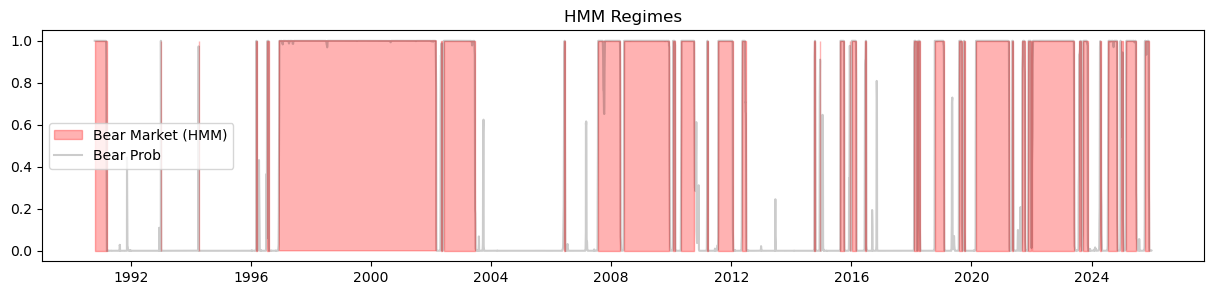

Statistik nach Regimes:
             Returns        VIX  Yield_Spread  HMM_Prob_Bear
HMM_Regime                                                  
0           0.000486  14.656819      1.751992       0.016791
1           0.000234  25.718460      1.288794       0.989676
            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-10-18      0.023363       0.006586  0.016652            0.902546   
1990-10-19      0.022045       0.008724  0.016716            0.917633   
1990-10-22      0.007296      -0.001081  0.003946            0.921254   
1990-10-23     -0.007625      -0.002165 -0.005441            0.916241   
1990-10-24      0.000768      -0.001085  0.000027            0.916266   
...                  ...            ...       ...                 ...   
2025-12-23      0.004550       0.001255  0.003232           20.224213   
2025-12-24      0.003221       0.005013  0.003938           20.303854   
20

In [36]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# 1. Auswahl der sinnvollen Features
# Returns (Performance), VIX (Angst) und Yield_Spread (Makro)
hmm_features = ['Returns', 'VIX', 'Yield_Spread']
X_hmm = df[hmm_features].values

# 2. Skalierung (Standardisierung auf Mittelwert 0 und Varianz 1)
scaler_hmm = StandardScaler()
X_hmm_scaled = scaler_hmm.fit_transform(X_hmm)

# 3. HMM Modellierung
# n_components=2 für Bull/Bear
model_hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, random_state=42)
model_hmm.fit(X_hmm_scaled)

# 4. Regimes und Wahrscheinlichkeiten vorhersagen
# predict() liefert 0 oder 1
# predict_proba() liefert die Wahrscheinlichkeit für beide Zustände [Prob_0, Prob_1]
hmm_regimes_raw = model_hmm.predict(X_hmm_scaled)
hmm_probs_raw = model_hmm.predict_proba(X_hmm_scaled)

# 5. Logik zur Sortierung: Welches ist das "Bear"-Regime?
# Wir definieren Bear (1) als das Regime mit der höheren Volatilität der Renditen.
state_0_vol = df['Returns'][hmm_regimes_raw == 0].std()
state_1_vol = df['Returns'][hmm_regimes_raw == 1].std()

# Wir wollen, dass Regime 1 immer "Bear" ist (höhere Vola)
if state_1_vol > state_0_vol:
    # Fall: Modell-Zustand 1 ist bereits der Bear-Markt
    df['HMM_Prob_Bear'] = hmm_probs_raw[:, 1]
    df['HMM_Regime'] = hmm_regimes_raw
else:
    # Fall: Modell-Zustand 0 war eigentlich der Bear-Markt -> wir flippen alles
    df['HMM_Prob_Bear'] = hmm_probs_raw[:, 0]
    df['HMM_Regime'] = 1 - hmm_regimes_raw

# 6. Visualisierung
plt.figure(figsize=(15, 3))
plt.fill_between(df.index, 0, 1, where=(df['HMM_Regime'] == 1), 
                 color='red', alpha=0.3, label='Bear Market (HMM)')
plt.plot(df.index, df['HMM_Prob_Bear'], color='black', alpha=0.2, label='Bear Prob') # Optional: Wahrscheinlichkeitslinie
plt.title("HMM Regimes")
plt.legend()
plt.show()

# Check: Durchschnittliche Renditen pro Regime
print("Statistik nach Regimes:")
print(df.groupby('HMM_Regime')[['Returns', 'VIX', 'Yield_Spread', 'HMM_Prob_Bear']].mean())

print(df)

Beide Markov-Modelle erfolgreich berechnet.


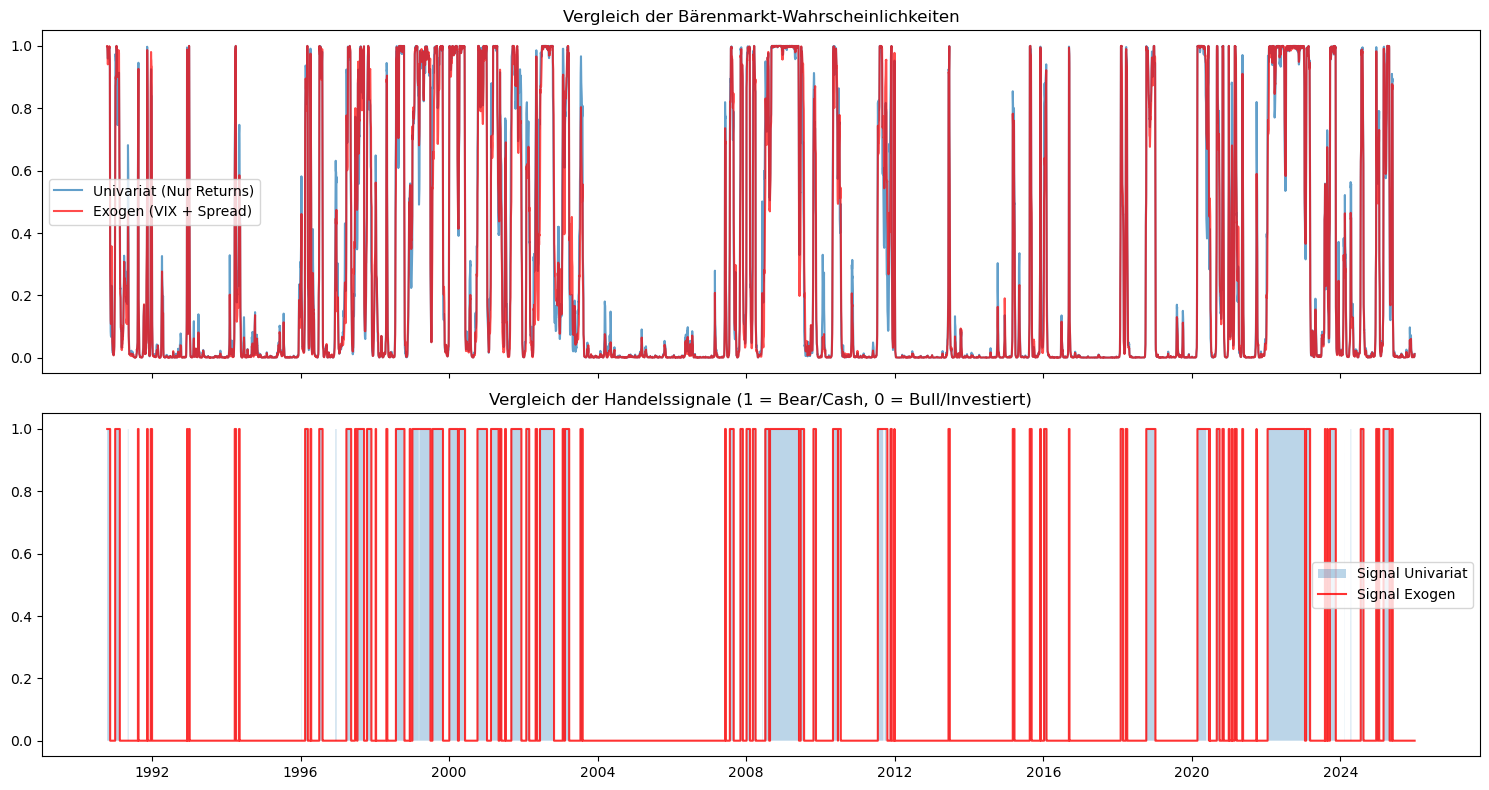

            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
1990-10-18      0.023363       0.006586  0.016652            0.902546   
1990-10-19      0.022045       0.008724  0.016716            0.917633   
1990-10-22      0.007296      -0.001081  0.003946            0.921254   
1990-10-23     -0.007625      -0.002165 -0.005441            0.916241   
1990-10-24      0.000768      -0.001085  0.000027            0.916266   
...                  ...            ...       ...                 ...   
2025-12-23      0.004550       0.001255  0.003232           20.224213   
2025-12-24      0.003221       0.005013  0.003938           20.303854   
2025-12-26     -0.000304      -0.002494 -0.001180           20.279893   
2025-12-29     -0.003492       0.003750 -0.000595           20.267821   
2025-12-30     -0.001376      -0.001245 -0.001323           20.240997   

            Cash_Returns    Vol_20    SMA_200  Dis

In [37]:
# --- 1. Markov-Switching-Modelle (Univariat vs. Exogen) ---
import statsmodels.api as sm
import warnings

# Warnung ignorieren
warnings.filterwarnings("ignore")

# 1. Vorbereitung: Index auf Business Days setzen
df.index = pd.DatetimeIndex(df.index).to_period('B')

# --- TEIL A: UNIVARIATES MODELL (Baseline) ---
# Nur Returns zur Bestimmung von Mittelwert und Varianz
ms_uni_model = sm.tsa.MarkovRegression(df['Returns'], k_regimes=2, switching_variance=True)
ms_uni_results = ms_uni_model.fit()

# Identifikation des Bärenmarktes (Regime mit der höheren Varianz)
prob_uni_regime_1 = ms_uni_results.smoothed_marginal_probabilities[1]
if ms_uni_results.params['sigma2[1]'] > ms_uni_results.params['sigma2[0]']:
    df['MS_Univariate_Prob_Bear'] = prob_uni_regime_1
else:
    df['MS_Univariate_Prob_Bear'] = 1 - prob_uni_regime_1

# Signal generieren
df['MS_Univariate_Signal'] = (df['MS_Univariate_Prob_Bear'] > 0.5).astype(int)


# --- TEIL B: EXOGENES MODELL (Erweitert) ---
# Returns als Ziel, VIX und Yield_Spread als erklärende Variablen (exog)
# Hinweis: Die exogenen Variablen beeinflussen hier die Mittelwert-Gleichung der Regimes
exo_vars = df[['VIX', 'Yield_Spread']]
ms_exo_model = sm.tsa.MarkovRegression(df['Returns'], k_regimes=2, exog=exo_vars, switching_variance=True)
ms_exo_results = ms_exo_model.fit()

# Identifikation des Bärenmarktes (Regime mit der höheren Varianz)
prob_exo_regime_1 = ms_exo_results.smoothed_marginal_probabilities[1]
if ms_exo_results.params['sigma2[1]'] > ms_exo_results.params['sigma2[0]']:
    df['MS_Exo_Prob_Bear'] = prob_exo_regime_1
else:
    df['MS_Exo_Prob_Bear'] = 1 - prob_exo_regime_1

# Signal generieren
df['MS_Exo_Signal'] = (df['MS_Exo_Prob_Bear'] > 0.5).astype(int)


# --- ABSCHLUSS ---
# Index wieder zurück in normales Datetime-Format für Plotting
df.index = df.index.to_timestamp()

print("Beide Markov-Modelle erfolgreich berechnet.")

# --- VISUALISIERUNG IM VERGLEICH ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Plot Wahrscheinlichkeiten
ax1.plot(df.index, df['MS_Univariate_Prob_Bear'], label='Univariat (Nur Returns)', alpha=0.7)
ax1.plot(df.index, df['MS_Exo_Prob_Bear'], label='Exogen (VIX + Spread)', alpha=0.7, color='red')
ax1.set_title("Vergleich der Bärenmarkt-Wahrscheinlichkeiten")
ax1.legend()

# Plot Signale
ax2.fill_between(df.index, 0, df['MS_Univariate_Signal'], alpha=0.3, label='Signal Univariat')
ax2.step(df.index, df['MS_Exo_Signal'], color='red', where='post', label='Signal Exogen', alpha=0.8)
ax2.set_title("Vergleich der Handelssignale (1 = Bear/Cash, 0 = Bull/Investiert)")
ax2.legend()

plt.tight_layout()
plt.show()

# Kurzer Blick auf das Ergebnis
print(df)

LSTM nutzt folgende Features: ['Returns', 'Vol_20', 'Distance_SMA', 'Momentum', 'VIX', 'Yield_Spread']
Starte LSTM Training...
Epoch 1/30
199/199 [==============================] - 4s 12ms/step - loss: 0.4209 - accuracy: 0.8123 - val_loss: 0.2679 - val_accuracy: 0.8879
Epoch 2/30
199/199 [==============================] - 2s 10ms/step - loss: 0.3390 - accuracy: 0.8591 - val_loss: 0.2839 - val_accuracy: 0.8837
Epoch 3/30
199/199 [==============================] - 2s 10ms/step - loss: 0.3186 - accuracy: 0.8673 - val_loss: 0.2333 - val_accuracy: 0.9007
Epoch 4/30
199/199 [==============================] - 2s 10ms/step - loss: 0.3069 - accuracy: 0.8683 - val_loss: 0.2044 - val_accuracy: 0.9277
Epoch 5/30
199/199 [==============================] - 2s 10ms/step - loss: 0.2939 - accuracy: 0.8771 - val_loss: 0.1995 - val_accuracy: 0.9248
Epoch 6/30
199/199 [==============================] - 2s 10ms/step - loss: 0.2850 - accuracy: 0.8815 - val_loss: 0.1871 - val_accuracy: 0.9319
Epoch 7/30
199/

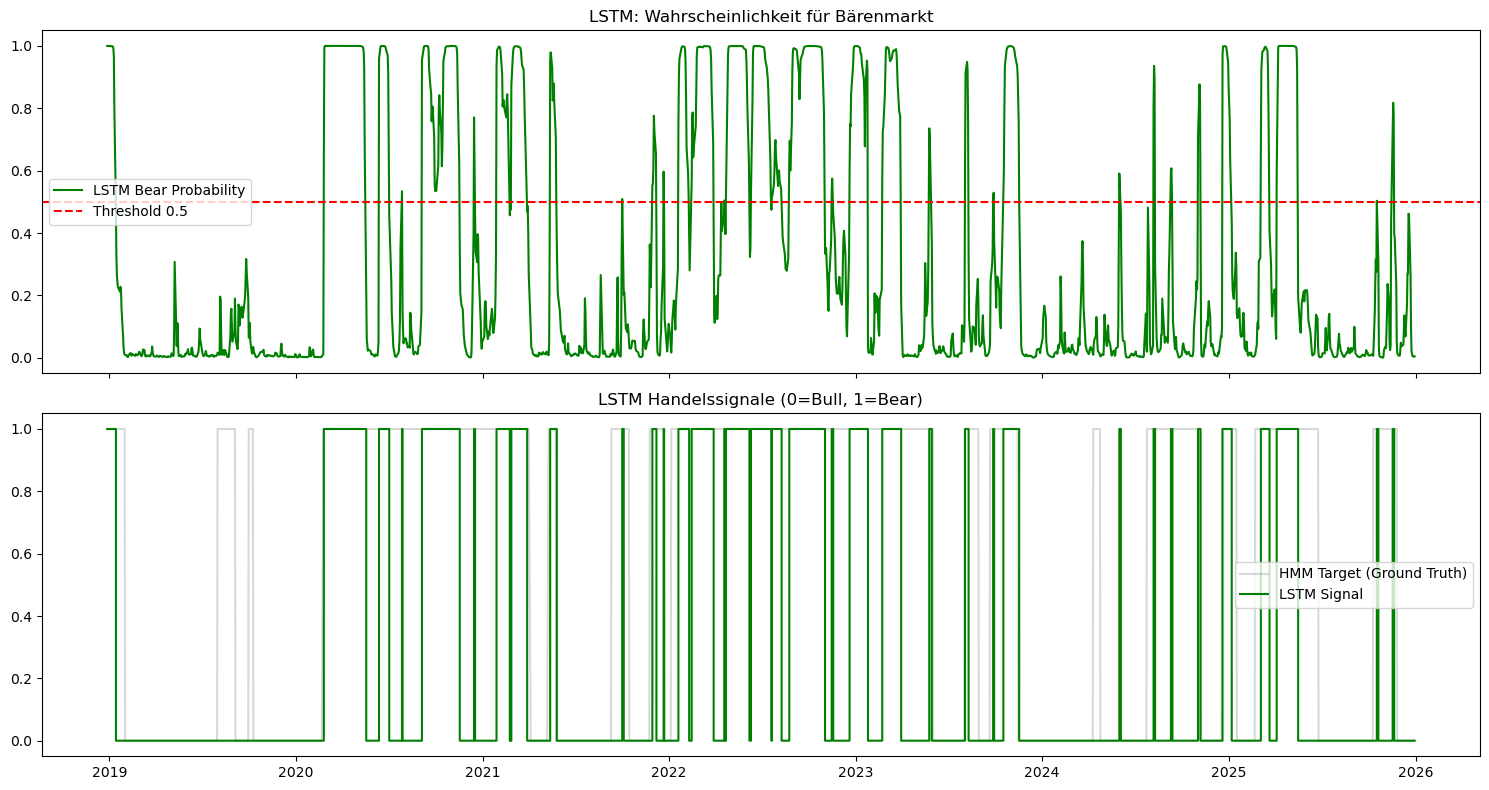

Finale Test-Genauigkeit: 92.62%
            Returns_GSPC  Returns_VUSTX   Returns  Cumulative_Returns  \
Date                                                                    
2018-12-28     -0.001242       0.008547  0.002674           10.136212   
2018-12-31      0.008492       0.005012  0.007100           10.208183   
2019-01-02      0.001268       0.005917  0.003128           10.240113   
2019-01-03     -0.024757       0.010924 -0.010484           10.132752   
2019-01-04      0.034336      -0.010806  0.016279           10.297703   
...                  ...            ...       ...                 ...   
2025-12-23      0.004550       0.001255  0.003232           20.224213   
2025-12-24      0.003221       0.005013  0.003938           20.303854   
2025-12-26     -0.000304      -0.002494 -0.001180           20.279893   
2025-12-29     -0.003492       0.003750 -0.000595           20.267821   
2025-12-30     -0.001376      -0.001245 -0.001323           20.240997   

            Cash_R

In [38]:
# --- LSTM-Netzwerk ---

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# 1. Features auswählen
# Wir nehmen alle relevanten Informationen für ein "ganzheitliches" Bild
features = ['Returns', 'Vol_20', 'Distance_SMA', 'Momentum', 'VIX', 'Yield_Spread']
print(f"LSTM nutzt folgende Features: {features}")

# Skalierung
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

def create_sequences(data, target, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(target[i])
    return np.array(X), np.array(y)

window_size = 30 # Beobachtungszeitraum: 30 Tage

# Wahl der passenden Labels
# Auf Basis von HMM-Regimes als Labels
#X, y = create_sequences(scaled_data, df['HMM_Regime'].values, window_size)
# Auf Basis von Markov-Regimes als Labels
X, y = create_sequences(scaled_data, df['MS_Univariate_Signal'].values, window_size)
#X, y = create_sequences(scaled_data, df['MS_Exo_Signal'].values, window_size)

# Split (Train/Test) - 80% Training, 20% Test
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 2. LSTM Architektur
model_lstm = Sequential([
    # input_shape passt sich automatisch an die Anzahl der Features an
    LSTM(64, return_sequences=True, input_shape=(window_size, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Binäre Klassifikation
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
print("Starte LSTM Training...")
history = model_lstm.fit(X_train, y_train, epochs=30, batch_size=32, 
                         validation_split=0.1, verbose=1)

# 3. Vorhersagen generieren
lstm_probs_raw = model_lstm.predict(X_test)

# --- Test-DataFrame für Backtesting und Visualisierung vorbereiten ---
# Wir schneiden das df so zu, dass es exakt zu den X_test Daten passt
test_df = df.iloc[split + window_size:].copy()

# Wahrscheinlichkeiten und Signale speichern
test_df['LSTM_Prob_Bear'] = lstm_probs_raw.flatten()
# Signale generieren
test_df['LSTM_Signal'] = (test_df['LSTM_Prob_Bear'] > 0.5).astype(int)

# --- Visualisierung der Ergebnisse (analog zu Markov-Modell) ---

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# A. Wahrscheinlichkeiten
ax1.plot(test_df.index, test_df['LSTM_Prob_Bear'], color='green', label='LSTM Bear Probability')
ax1.axhline(y=0.5, color='red', linestyle='--', label='Threshold 0.5')
ax1.set_title("LSTM: Wahrscheinlichkeit für Bärenmarkt")
ax1.legend()

# B. Signale im Vergleich zum HMM-Label (Grundwahrheit)
ax2.plot(test_df.index, test_df['HMM_Regime'], label='HMM Target (Ground Truth)', alpha=0.3, color='gray')
ax2.step(test_df.index, test_df['LSTM_Signal'], where='post', label='LSTM Signal', color='green')
ax2.set_title("LSTM Handelssignale (0=Bull, 1=Bear)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Finale Test-Genauigkeit: {history.history['val_accuracy'][-1]:.2%}")

print(test_df)

# --- Wir wechseln in diesem Schritt von df auf test_df da sich der Beobachtungszeitraum eingrenzt ---

### Phase 5: Backtesting-Strategie
Wir plotten zunächst die Regime-Wahrscheinlichkeiten der Modelle sowie der tatsächlichen Modell-Signale.

Anschließend testen wir den Erfolg einer Investition in Abhängigkeit zum gewählten Modell und den unten beschriebenen Regeln.

*   **Regel:**
    *   Wenn Modell sagt "Bull": 100% Aktien (S&P 500).
    *   Wenn Modell sagt "Bear": 100% Bonds oder Cash.
*   **Transaktionskosten:** Integriere realistische Kosten (z.B. 0,1% pro Trade), da ML-Modelle oft zu nervös hin- und herschalten ("Churning").

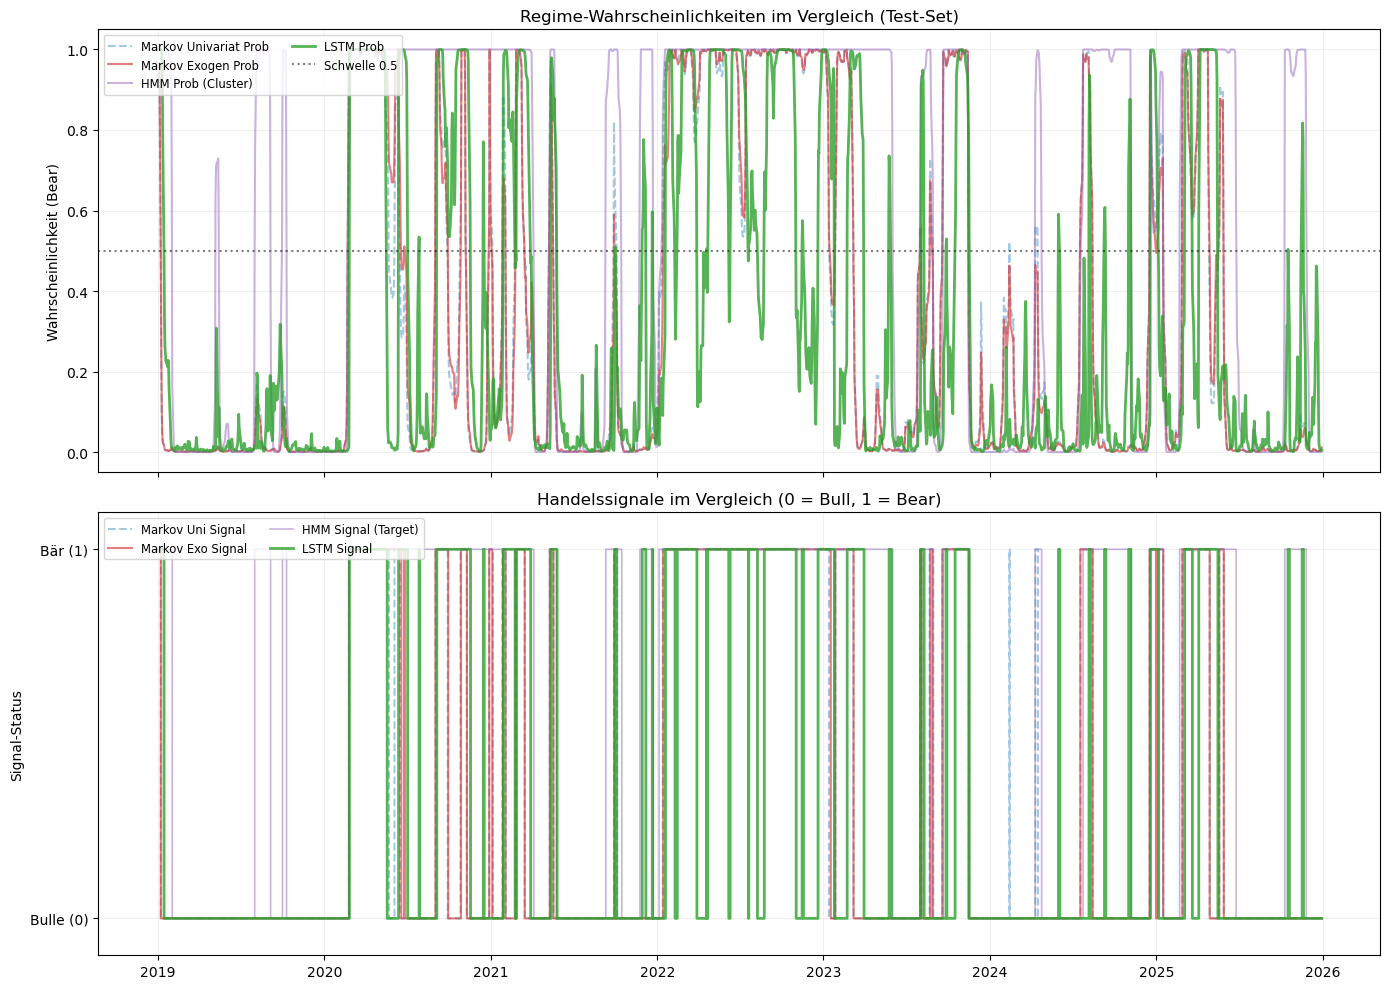

In [43]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Plot 1: Wahrscheinlichkeiten (Probabilities) ---
# Markov Univariat (Blau)
ax1.plot(test_df.index, test_df['MS_Univariate_Prob_Bear'], 
         label='Markov Univariat Prob', alpha=0.4, color='tab:blue', linestyle='--')

# Markov Exogen (Rot)
ax1.plot(test_df.index, test_df['MS_Exo_Prob_Bear'], 
         label='Markov Exogen Prob', alpha=0.6, color='tab:red')

# HMM (Lila)
ax1.plot(test_df.index, test_df['HMM_Prob_Bear'], 
         label='HMM Prob (Cluster)', alpha=0.5, color='tab:purple')

# LSTM (Grün)
ax1.plot(test_df.index, test_df['LSTM_Prob_Bear'], 
         label='LSTM Prob', alpha=0.8, color='tab:green', linewidth=2)

ax1.axhline(y=0.5, color='black', linestyle=':', alpha=0.5, label='Schwelle 0.5')
ax1.set_title("Regime-Wahrscheinlichkeiten im Vergleich (Test-Set)")
ax1.set_ylabel("Wahrscheinlichkeit (Bear)")
ax1.legend(loc='upper left', fontsize='small', ncol=2)
ax1.grid(alpha=0.2)
ax1.set_ylim(-0.05, 1.05)

# --- Plot 2: Binäne Signale (0 oder 1) ---
ax2.step(test_df.index, test_df['MS_Univariate_Signal'], 
         where='post', label='Markov Uni Signal', alpha=0.4, color='tab:blue', linestyle='--')

ax2.step(test_df.index, test_df['MS_Exo_Signal'], 
         where='post', label='Markov Exo Signal', alpha=0.6, color='tab:red')

# HMM (Lila)
ax2.step(test_df.index, test_df['HMM_Regime'], 
         where='post', label='HMM Signal (Target)', alpha=0.5, color='tab:purple', linewidth=1.2)

ax2.step(test_df.index, test_df['LSTM_Signal'], 
         where='post', label='LSTM Signal', alpha=0.8, color='tab:green', linewidth=2)

ax2.set_title("Handelssignale im Vergleich (0 = Bull, 1 = Bear)")
ax2.set_ylabel("Signal-Status")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Bulle (0)', 'Bär (1)'])
ax2.legend(loc='upper left', fontsize='small', ncol=2)
ax2.grid(alpha=0.2)
ax2.set_ylim(-0.1, 1.1)

# Layout optimieren
plt.tight_layout()
# Equity Curve persistieren
plt.savefig('../assets/regime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

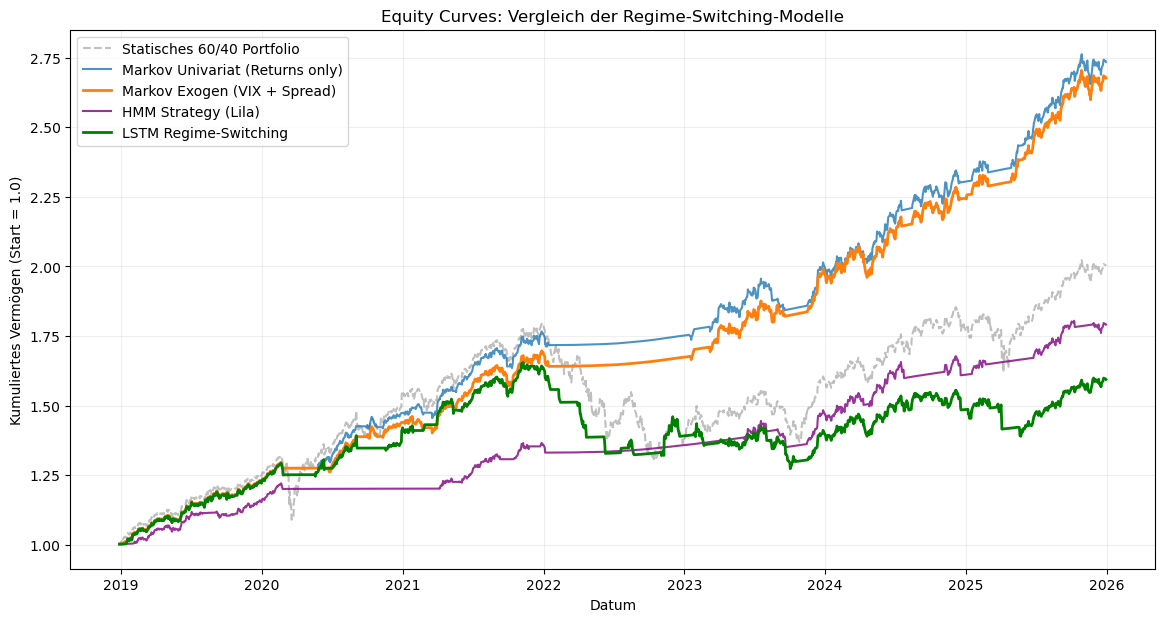


--- Finale Performance-Kennzahlen (Test-Zeitraum) ---
Buy_Hold            : 2.0022 (+100.22%)
MS_Univariate       : 2.7341 (+173.41%)
MS_Exogenous        : 2.6765 (+167.65%)
LSTM_Regime         : 1.5941 (+59.41%)
HMM_Based           : 1.7910 (+79.10%)

--- Maximum Drawdown Vergleich ---
Buy_Hold            : -27.10%
MS_Univariate       : -5.80%
MS_Exogenous        : -5.44%
LSTM_Regime         : -23.05%
HMM_Based           : -6.53%


In [42]:
# --- 5. Erweitertes Backtesting (Vergleich aller Strategien) ---

def backtest(df, signal_col):
    """
    Berechnet die kumulierte Rendite einer Strategie.
    Bull (0): Investiert im 60/40 Portfolio
    Bear (1): Investiert im Geldmarkt (Cash_Returns)
    """
    # WICHTIG: Signal um 1 Tag verschieben! 
    # Wir handeln HEUTE basierend auf dem Signal, das GESTERN ABEND vorlag.
    trading_signal = df[signal_col].shift(1).fillna(0)
    
    # Logik: Wenn Signal 0 -> Portfolio-Return, sonst Cash-Return
    strategy_returns = np.where(trading_signal == 0, 
                                df['Returns'], 
                                df['Cash_Returns'])
    
    # Kumulierte Rendite berechnen (Startwert 1.0)
    return (1 + strategy_returns).cumprod()

# Ergebnisse in ein neues DataFrame für den Vergleich schreiben
backtesting_results = pd.DataFrame(index=test_df.index)

# 1. Benchmark: Statisches Buy & Hold (60% Aktien / 40% Anleihen)
backtesting_results['Buy_Hold'] = (1 + test_df['Returns']).cumprod()

# 2. Strategie: Markov Univariat (Nur basierend auf Rendite-Statistik)
backtesting_results['MS_Univariate'] = backtest(test_df, 'MS_Univariate_Signal')

# 3. Strategie: Markov Exogen (Inklusive VIX & Yield Spread)
backtesting_results['MS_Exogenous'] = backtest(test_df, 'MS_Exo_Signal')

# 4. Strategie: LSTM-Regime (Deep Learning Vorhersage)
backtesting_results['LSTM_Regime'] = backtest(test_df, 'LSTM_Signal')

# 5. Strategie: HMM-Regime
backtesting_results['HMM_Based'] = backtest(test_df, 'HMM_Regime')

# --- Visualisierung ---
plt.figure(figsize=(14, 7))

# Buy & Hold als graue Basislinie
plt.plot(backtesting_results['Buy_Hold'], label='Statisches 60/40 Portfolio', color='gray', alpha=0.5, linestyle='--')

# Die aktiven Strategien
plt.plot(backtesting_results['MS_Univariate'], label='Markov Univariat (Returns only)', alpha=0.8)
plt.plot(backtesting_results['MS_Exogenous'], label='Markov Exogen (VIX + Spread)', linewidth=2)
plt.plot(backtesting_results['HMM_Based'], label='HMM Strategy (Lila)', color='purple', linewidth=1.5, alpha=0.8)
plt.plot(backtesting_results['LSTM_Regime'], label='LSTM Regime-Switching', linewidth=2, color='green')

plt.title("Equity Curves: Vergleich der Regime-Switching-Modelle")
plt.xlabel("Datum")
plt.ylabel("Kumuliertes Vermögen (Start = 1.0)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
# Equity Curve persistieren
plt.savefig('../assets/equity_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Performance Auswertung ---
print("\n--- Finale Performance-Kennzahlen (Test-Zeitraum) ---")
final_wealth = backtesting_results.iloc[-1]
for strategy, wealth in final_wealth.items():
    total_return = (wealth - 1) * 100
    print(f"{strategy:20s}: {wealth:.4f} ({total_return:+.2f}%)")

# Optional: Kurze Berechnung des Max Drawdowns für den schnellen Check
def calc_max_drawdown(series):
    roll_max = series.cummax()
    drawdown = series / roll_max - 1.0
    return drawdown.min()

print("\n--- Maximum Drawdown Vergleich ---")
for col in backtesting_results.columns:
    mdd = calc_max_drawdown(backtesting_results[col])
    print(f"{col:20s}: {mdd:.2%}")

### Phase 6: Evaluation & Vergleich (Der Kern der Thesis)
Beweis des Mehrwerts zur Reduktion des **Sequence of Returns Risk**.
*   **Metriken:**
    *   **Maximum Drawdown (MDD):** Wie tief war der maximale Fall? (Wichtigstes Ziel).
    *   **Sharpe Ratio / Sortino Ratio:** Risiko-adjustierte Rendite.
    *   **Calmar Ratio:** Rendite im Verhältnis zum Drawdown.
    *   **Regime-Stabilität:** Wie oft schaltet das Modell um? (LSTMs neigen zum "Overfitting" und Rauschen).

In [41]:
def evaluate_strategies(results_df, trades_df):
    """
    Umfassende Evaluation der Backtesting-Ergebnisse.
    results_df: DataFrame mit kumulierten Werten (Equity Curves)
    trades_df: DataFrame mit den binären Signalen (um Handelsfrequenz zu messen)
    """
    stats = []
    
    for col in results_df.columns:
        equity_curve = results_df[col]
        daily_returns = equity_curve.pct_change().dropna()
        
        # 1. Total Return & CAGR (Annualisierte Rendite)
        total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1
        days = (equity_curve.index[-1] - equity_curve.index[0]).days
        cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0])**(365.25/days) - 1
        
        # 2. Volatilität (annualisiert)
        vol = daily_returns.std() * np.sqrt(252)
        
        # 3. Sharpe Ratio (Annahme: Risk-Free Rate = 0, da Cash bereits in Strategie steckt)
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252) if daily_returns.std() != 0 else 0
        
        # 4. Maximum Drawdown
        peak = equity_curve.expanding(min_periods=1).max()
        drawdown = (equity_curve / peak) - 1
        mdd = drawdown.min()
        
        # 5. Sortino Ratio (Fokus auf Downside-Risiko)
        downside_returns = daily_returns[daily_returns < 0]
        downside_std = downside_returns.std() * np.sqrt(252)
        sortino = (daily_returns.mean() * 252) / downside_std if downside_std != 0 else np.nan
        
        # 6. Calmar Ratio (Verhältnis Rendite zu Max Drawdown)
        calmar = cagr / abs(mdd) if mdd != 0 else np.nan
        
        # 7. Anzahl der Trades (Regime-Wechsel)
        # Wir messen, wie oft das Modell von 0 auf 1 oder umgekehrt springt
        if col in trades_df.columns:
            # Signaländerungen zählen (Absolutwert der Differenz)
            switches = trades_df[col].diff().abs().sum()
        else:
            switches = 0 # Buy & Hold hat 0 Wechsel
            
        stats.append({
            'Strategie': col,
            'Total Return': f"{total_return:.2%}",
            'CAGR (p.a.)': f"{cagr:.2%}",
            'Volatilität': f"{vol:.2%}",
            'Max Drawdown': f"{mdd:.2%}",
            'Sharpe Ratio': round(sharpe, 2),
            'Sortino Ratio': round(sortino, 2),
            'Calmar Ratio': round(calmar, 2),
            'Regime-Wechsel': int(switches)
        })
    
    return pd.DataFrame(stats).set_index('Strategie')

# Übergeben der Equity Curves und der Trade-Stratistik test_df mit den Signalen
# Mappen der Spaltennamen, damit die Funktion die Signale findet
signals_to_count = pd.DataFrame(index=test_df.index)
signals_to_count['MS_Univariate'] = test_df['MS_Univariate_Signal']
signals_to_count['MS_Exogenous'] = test_df['MS_Exo_Signal']
signals_to_count['LSTM_Regime'] = test_df['LSTM_Signal']
signals_to_count['HMM_Based'] = test_df['HMM_Regime']

evaluation_table = evaluate_strategies(backtesting_results, signals_to_count)

# Anzeige der Tabelle
print("\n--- UMFASSENDE EVALUATION ---")
display(evaluation_table)

# --- Wir erhalten in diesem Schritt neben df und test_df, results_df mit kumulierten Werten und trades_df mit binären Handelssignalen ---


--- UMFASSENDE EVALUATION ---


,Total Return,CAGR (p.a.),Volatilität,Max Drawdown,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Regime-Wechsel
Strategie,,,,,,,,
Buy_Hold,99.69%,10.37%,12.64%,-27.10%,0.85,1.09,0.38,0
MS_Univariate,172.68%,15.39%,6.30%,-5.80%,2.31,3.01,2.65,41
MS_Exogenous,166.94%,15.04%,6.40%,-5.44%,2.23,2.89,2.76,39
LSTM_Regime,58.99%,6.84%,8.15%,-23.05%,0.86,0.98,0.30,71
HMM_Based,78.63%,8.63%,4.89%,-6.53%,1.72,1.58,1.32,29
